<a href="https://colab.research.google.com/github/23151651/ISYS2001-23151651/blob/main/ISYS_A2_Personal_Finance_Tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#This is my A2 Finance tracker. Not my lab ticket in case you were wondering why I am using week 2's lab ticket 'layout' to do my tracker.

In [ ]:
#Week 2 stuff: asking for personalization
# Collect user information for their financial profile
user_name = input("What is your name? ")
theme_color = input("What color would you like for your app theme? (e.g., blue, green, dark) ")
primary_currency = input("What is your primary currency? (e.g., AUD, USD, EUR) ")
main_savings_goal = input("What is one big savings goal you have? (e.g., New Car, Holiday) ")

# Construct the personalized welcome message
summary = ("Welcome to your Personal Finance Tracker, " + user_name + "! Your profile is ready. " + \
           "The app will use a " + theme_color + " theme and all amounts will be in " + \
           primary_currency + ". Let's start working towards your goal of saving for a " + \
           main_savings_goal + "!")

# Display the summary message
print(summary)

What is your name? John
What color would you like for your app theme? (e.g., blue, green, dark) Dark
What is your primary currency? (e.g., AUD, USD, EUR) AUD
What is one big savings goal you have? (e.g., New Car, Holiday) New car
Welcome to your Personal Finance Tracker, John! Your profile is ready. The app will use a Dark theme and all amounts will be in AUD. Let's start working towards your goal of saving for a New car!


In [ ]:

#Week 3: Budgeting (non changeable)
def get_positive_number(prompt):
    """
    Repeatedly asks the user for a positive number until valid input is entered.
    """
    while True:
        try:
            value = float(input(prompt))
            if value < 0:
                print("Error: Please enter a positive number or 0.")
            else:
                return value
        except ValueError:
            print("Error: Invalid input. Please enter a number.")


def get_expenses():
    """
    Collects monthly expenses from the user and stores them in a dictionary.
    """
    expenses = {
        "Rent or Mortgage": get_positive_number("Enter Rent or Mortgage: $"),
        "Utilities": get_positive_number("Enter Utilities: $"),
        "Groceries": get_positive_number("Enter Groceries: $"),
        "Transport": get_positive_number("Enter Transport: $"),
        "Entertainment": get_positive_number("Enter Entertainment: $"),
        "Savings": get_positive_number("Enter Savings: $"),
        "Other Expenses": get_positive_number("Enter Other Expenses: $")
    }
    return expenses


def calculate_budget(income, expenses):
    """
    Calculates total expenses, remaining balance,
    and percentage of income spent for each category.
    """
    total_expenses = sum(expenses.values())
    remaining_balance = income - total_expenses

    percentages = {}
    if income > 0:
        for category, amount in expenses.items():
            percentages[category] = (amount / income) * 100
    else:
        for category in expenses:
            percentages[category] = 0

    return total_expenses, remaining_balance, percentages


def display_summary(income, expenses, total_expenses, remaining_balance, percentages):
    """
    Displays a formatted budget summary.
    """
    print("\n" + "=" * 40)
    print("         MONTHLY BUDGET SUMMARY")
    print("=" * 40)
    print(f"Monthly Income:      ${income:.2f}\n")

    print("Expenses:")
    for category, amount in expenses.items():
        print(f"{category:<20} ${amount:>8.2f} "
              f"({percentages[category]:>5.1f}%)")

    print("-" * 40)
    print(f"Total Expenses:      ${total_expenses:.2f}")
    print(f"Remaining Balance:   ${remaining_balance:.2f}")
    print("=" * 40)

    # Budget message
    if remaining_balance > 0:
        print("Great job! You are saving money each month.")
    elif remaining_balance == 0:
        print("Your budget is perfectly balanced.")
    else:
        print("Warning: You are spending more than you earn!")
    print("=" * 40)


def main():
    """
    Main program loop.
    """
    print("Welcome to the Monthly Budget Calculator!")

    while True:
        # Get monthly income
        income = get_positive_number("\nEnter your monthly income: $")

        # Get expenses
        expenses = get_expenses()

        # Calculate results
        total_expenses, remaining_balance, percentages = calculate_budget(
            income, expenses
        )

        # Display summary
        display_summary(
            income,
            expenses,
            total_expenses,
            remaining_balance,
            percentages
        )

        # Ask if the user wants to calculate another budget
        while True:
            again = input(
                "\nWould you like to calculate another budget? (yes/no): "
            ).strip().lower()

            if again == "yes":
                break
            elif again == "no":
                print("\nThank you for using the Budget Calculator. Goodbye!")
                return
            else:
                print("Please enter 'yes' or 'no'.")


# Run the program
if __name__ == "__main__":
    main()

Welcome to the Monthly Budget Calculator!

Enter your monthly income: $3000
Enter Rent or Mortgage: $200
Enter Utilities: $1000
Enter Groceries: $30
Enter Transport: $50
Enter Entertainment: $10
Enter Savings: $50
Enter Other Expenses: $2

         MONTHLY BUDGET SUMMARY
Monthly Income:      $3000.00

Expenses:
Rent or Mortgage     $  200.00 (  6.7%)
Utilities            $ 1000.00 ( 33.3%)
Groceries            $   30.00 (  1.0%)
Transport            $   50.00 (  1.7%)
Entertainment        $   10.00 (  0.3%)
Savings              $   50.00 (  1.7%)
Other Expenses       $    2.00 (  0.1%)
----------------------------------------
Total Expenses:      $1342.00
Remaining Balance:   $1658.00
Great job! You are saving money each month.

Would you like to calculate another budget? (yes/no): no

Thank you for using the Budget Calculator. Goodbye!


In [ ]:
#Week Data A

def calculate_percentage(amount, total):
    """
    Calculate what percentage amount is of total.

    Parameters:
    amount (float): The partial amount
    total (float): The total amount

    Returns:
    float: Percentage (0-100), or 0 if total is 0

    Example: calculate_percentage(250, 1000) returns 25.0
    """
    if total == 0:
        return 0
    return (amount / total) * 100

def categorize_expense(amount, monthly_budget):
    """
    Categorize an expense based on budget percentage.

    Parameters:
    amount (float): Expense amount
    monthly_budget (float): Total monthly budget

    Returns:
    str: "Major Expense" (≥20%), "Moderate Expense" (5-19%), or "Minor Expense" (<5%)

    Example: categorize_expense(200, 1000) returns "Moderate Expense"
    """
    # Hint: Use the calculate_percentage() function you just defined!
    percentage = calculate_percentage(amount, monthly_budget)

    if percentage >= 20:
        return "Major Expense"
    elif percentage >= 5:
        return "Moderate Expense"
    else:
        return "Minor Expense"

def calculate_monthly_payment(principal, annual_rate, months):
    """
    Calculate monthly loan payment using simple formula.

    Parameters:
    principal (float): Loan amount
    annual_rate (float): Annual interest rate (as percentage, e.g., 5.5)
    months (int): Number of months

    Returns:
    float: Monthly payment amount

    Example: calculate_monthly_payment(10000, 5.0, 12) returns ~858.33
    """
    # Handle the case where annual_rate is 0 (no interest)
    if annual_rate == 0:
        return principal / months

    monthly_rate = annual_rate / 12 / 100
    return principal * (monthly_rate * (1 + monthly_rate)**months) / ((1 + monthly_rate)**months - 1)

print("Core financial functions defined successfully!")
print("Test them in the next cell...")

Core financial functions defined successfully!
Test them in the next cell...


In [ ]:
#Week 5 data testing B
print("Testing calculate_percentage:")
print(f"250 out of 1000: {calculate_percentage(250, 1000)}%")  # Should be 25.0
print(f"0 out of 500: {calculate_percentage(0, 500)}%")        # Should be 0.0
print(f"100 out of 0: {calculate_percentage(100, 0)}%")        # Should be 0.0

print("\nTesting categorize_expense:")
print(f"$200 of $1000 budget: {categorize_expense(200, 1000)}")   # Should be "Moderate Expense"
print(f"$50 of $1000 budget: {categorize_expense(50, 1000)}")     # Should be "Minor Expense"
print(f"$250 of $1000 budget: {categorize_expense(250, 1000)}")   # Should be "Major Expense"

print("\nTesting calculate_monthly_payment:")
print(f"$10,000 at 5% for 12 months: ${calculate_monthly_payment(10000, 5.0, 12):.2f}")
print(f"$5,000 at 0% for 24 months: ${calculate_monthly_payment(5000, 0, 24):.2f}")

Testing calculate_percentage:
250 out of 1000: 25.0%
0 out of 500: 0.0%
100 out of 0: 0%

Testing categorize_expense:
$200 of $1000 budget: Major Expense
$50 of $1000 budget: Moderate Expense
$250 of $1000 budget: Major Expense

Testing calculate_monthly_payment:
$10,000 at 5% for 12 months: $856.07
$5,000 at 0% for 24 months: $208.33


In [ ]:
#Week 5 Data C

def find_largest_expense(expenses):
    """
    Find the largest expense in a list.

    Parameters:
    expenses (list): List of expense amounts

    Returns:
    float: Largest expense, or 0 if list is empty
    """
    if not expenses:  # Empty list
        return 0
    return max(expenses)

def find_smallest_expense(expenses):
    """
    Find the smallest expense in a list.

    Parameters:
    expenses (list): List of expense amounts

    Returns:
    float: Smallest expense, or 0 if list is empty
    """
    if not expenses:
        return 0
    return min(expenses)

def calculate_average_expense(expenses):
    """
    Calculate average expense amount.

    Parameters:
    expenses (list): List of expense amounts

    Returns:
    float: Average expense, or 0 if list is empty
    """
    if not expenses:
        return 0
    return sum(expenses) / len(expenses)

def count_expenses_by_category(expenses, monthly_budget):
    """
    Count expenses by category using the categorize_expense function.

    Parameters:
    expenses (list): List of expense amounts
    monthly_budget (float): Monthly budget for categorization

    Returns:
    dict: Dictionary with counts for each category
    Example: {"Major": 2, "Moderate": 5, "Minor": 8}
    """
    # Hint: Use the categorize_expense() function from Cell 1!
    categories = {"Major": 0, "Moderate": 0, "Minor": 0}

    for expense in expenses:
        category = categorize_expense(expense, monthly_budget)
        if "Major" in category:
            categories["Major"] += 1
        elif "Moderate" in category:
            categories["Moderate"] += 1
        else:
            categories["Minor"] += 1

    return categories

def calculate_total_spent(expenses):
    """
    Calculate total amount spent.

    Parameters:
    expenses (list): List of expense amounts

    Returns:
    float: Total spent
    """
    return sum(expenses) if expenses else 0

print("Data analysis functions defined successfully!")
print("Test them in the next cell...")

Data analysis functions defined successfully!
Test them in the next cell...


In [ ]:
# Week 5 data D
test_expenses = [450, 67.50, 89, 25, 120, 15, 300]
test_budget = 2000

print("Testing analysis functions with sample expenses:")
print(f"Expenses: {test_expenses}")
print(f"Budget: ${test_budget}")
print()

print(f"Total spent: ${calculate_total_spent(test_expenses):.2f}")
print(f"Largest expense: ${find_largest_expense(test_expenses):.2f}")
print(f"Smallest expense: ${find_smallest_expense(test_expenses):.2f}")
print(f"Average expense: ${calculate_average_expense(test_expenses):.2f}")
print(f"Category counts: {count_expenses_by_category(test_expenses, test_budget)}")

# Test edge cases
empty_list = []
print(f"\nTesting with empty list:")
print(f"Total: ${calculate_total_spent(empty_list):.2f}")
print(f"Average: ${calculate_average_expense(empty_list):.2f}")

Testing analysis functions with sample expenses:
Expenses: [450, 67.5, 89, 25, 120, 15, 300]
Budget: $2000

Total spent: $1066.50
Largest expense: $450.00
Smallest expense: $15.00
Average expense: $152.36
Category counts: {'Major': 1, 'Moderate': 2, 'Minor': 4}

Testing with empty list:
Total: $0.00
Average: $0.00


In [ ]:
#Week 5 data E
def get_valid_amount(prompt):
    """
    Get a valid positive amount from user with input validation.

    Parameters:
    prompt (str): Message to display to user

    Returns:
    float: Valid positive amount
    """
    while True:
        try:
            amount = float(input(prompt))
            if amount > 0:
                return amount
            else:
                print("Amount must be positive! Please try again.")
        except ValueError:
            print("Please enter a valid number!")

def collect_expenses():
    """
    Collect multiple expenses from user using sentinel pattern.

    Returns:
    tuple: (list of expense amounts, list of expense descriptions)
    """
    expenses = []
    descriptions = []

    print("\n--- Enter Your Expenses ---")
    print("Type 'done' when finished entering expenses")

    while True:
        expense_input = input("\nExpense amount (or 'done'): $")

        if expense_input.lower() == 'done':
            break

        try:
            amount = float(expense_input)
            if amount > 0:
                description = input("What was this expense for? ")
                expenses.append(amount)
                descriptions.append(description)

                # Show running total
                total_so_far = calculate_total_spent(expenses)
                print(f"Added ${amount:.2f} for {description}")
                print(f"Running total: ${total_so_far:.2f} ({len(expenses)} expenses)")
            else:
                print("Amount must be positive!")
        except ValueError:
            print("Please enter a valid number or 'done'!")

    return expenses, descriptions

def display_expense_analysis(expenses, descriptions, monthly_budget):
    """
    Display comprehensive expense analysis using all our functions.

    Parameters:
    expenses (list): List of expense amounts
    descriptions (list): List of expense descriptions
    monthly_budget (float): User's monthly budget
    """
    if not expenses:
        print("\nNo expenses to analyze!")
        return

    print("\n" + "="*60)
    print("EXPENSE ANALYSIS REPORT")
    print("="*60)

    # Basic statistics using our functions
    total_spent = calculate_total_spent(expenses)
    budget_percentage = calculate_percentage(total_spent, monthly_budget)
    average_expense = calculate_average_expense(expenses)
    largest_expense = find_largest_expense(expenses)
    smallest_expense = find_smallest_expense(expenses)

    print(f"Financial Summary:")
    print(f"   Total expenses: {len(expenses)}")
    print(f"   Total spent: ${total_spent:.2f}")
    print(f"   Budget used: {budget_percentage:.1f}%")
    print(f"   Remaining budget: ${monthly_budget - total_spent:.2f}")
    print()

    print(f"Spending Analysis:")
    print(f"   Average expense: ${average_expense:.2f}")
    print(f"   Largest expense: ${largest_expense:.2f}")
    print(f"   Smallest expense: ${smallest_expense:.2f}")
    print()

    # Category breakdown using our function
    categories = count_expenses_by_category(expenses, monthly_budget)
    print(f"Expense Categories:")
    print(f"   Major expenses (≥20% of budget): {categories['Major']}")
    print(f"   Moderate expenses (5-19% of budget): {categories['Moderate']}")
    print(f"   Minor expenses (<5% of budget): {categories['Minor']}")
    print()

    # Detailed expense list
    print(f"Expense Details:")
    for i, (amount, description) in enumerate(zip(expenses, descriptions), 1):
        category = categorize_expense(amount, monthly_budget)
        percentage = calculate_percentage(amount, monthly_budget)
        print(f"   {i}. ${amount:.2f} - {description} ({category}, {percentage:.1f}% of budget)")
    print()

    # Smart advice based on spending
    print(f"Budget Advice:")
    if budget_percentage >= 90:
        print("    Danger zone! You've used most of your budget. Consider reducing expenses.")
    elif budget_percentage >= 75:
        print("   Approaching budget limit. Be cautious with remaining spending.")
    elif budget_percentage >= 50:
        print("   Halfway through budget. You're maintaining a good pace.")
    elif budget_percentage >= 25:
        print("   Good progress! You're spending conservatively.")
    else:
        print("   Excellent! You're well within budget with room for savings.")

def generate_timestamp():
    """
    Generate a formatted timestamp using datetime module.

    Returns:
    str: Formatted current date and time
    """
    from datetime import datetime
    current_time = datetime.now()
    return current_time.strftime("%Y-%m-%d %H:%M:%S")

print("User interface functions defined successfully!")
print("Ready to run the main program...")

User interface functions defined successfully!
Ready to run the main program...


In [ ]:
#week 5's finance tracker
def main():
    """Main program Message."""

    print("-" * 80)
    print("Personal Finance Tracker")
    print("-" * 80)

    # time stamp thing
    timestamp = generate_timestamp()
    print(f"Begin Session: {timestamp}")
    print()

    # first few questions
    name = input("What's your name? ")
    monthlybudget = get_valid_amount("How much money do you have per month?: $")

    # system stuff 1
    print(f"\nWelcome {name}. Congratulations for using this finance tracker, we're so glad you're here")
    print(f"Monthly Budget: ${monthlybudget:.2f}")
    print(f"Session time: {timestamp}")

    # expenses collection and analysis
    expenses, desc = collect_expenses()
    display_expense_analysis(expenses, desc, monthlybudget)

    # summary system stuff
    print("-" * 80)
    print("Session finished!")
    print("-" * 80)
    print(f"Thank you for using this financial tracker {name}! You tracked {len(expenses)} expenses.")

    if expenses:
        total = calculate_total_spent(expenses)
        percentage = calculate_percentage(total, monthlybudget)

    print("This thing can do more!")

    # return the information
    return {
        'name': name,
        'budget': monthlybudget,
        'expenses': expenses,
        'descriptions': desc,
        'timestamp': timestamp
    }


# system stuff 2
print("Starting things up...")
print("Functions from other cells are usable now!")
print()

session_date = main()

In [ ]:
#CSV upload code
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_csv("sales_data.csv")

print(df.head())

In [13]:
#Asked Chat GPT to make a finance tracker that involved a CSV file. I will attach the file.

import pandas as pd
from google.colab import files

# 1. Upload CSV file
print("PERSONAL FINANCE TRACKER")
print("-" * 40)
print("Please upload your finance CSV file.")

uploaded = files.upload()

# Get the uploaded filename
filename = next(iter(uploaded))


# 2. Read CSV using multiple encodings
encodings = ["utf-8", "cp1252", "latin1"]

df = None

for encoding in encodings:
    try:
        df = pd.read_csv(filename, encoding=encoding)
        print(f"\nFile successfully read using {encoding} encoding.")
        break

    except UnicodeDecodeError:
        print(f"{encoding} encoding did not work.")

    except pd.errors.ParserError:
        print(f"{encoding} encoding had a CSV formatting problem.")


# Stop if the file could not be read
if df is None:

    print("\nCould not read the CSV file.")
    print("Please check that it is a properly formatted CSV.")

else:

    # 3. Check that the required columns exist
    required_columns = [
        "Date",
        "Category",
        "Description",
        "Type",
        "Amount"
    ]

    if not all(column in df.columns for column in required_columns):

        print("\nERROR: Your CSV is missing required columns.")

        print("\nRequired columns:")
        print(required_columns)

        print("\nColumns found in your file:")
        print(list(df.columns))

    else:

        # 4. Keep only the required columns
        df = df[required_columns].copy()


        # 5. Clean the Amount column
        df["Amount"] = (
            df["Amount"]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip()
        )

        df["Amount"] = pd.to_numeric(
            df["Amount"],
            errors="coerce"
        )


        # 6. Clean the Date column
        df["Date"] = pd.to_datetime(
            df["Date"],
            errors="coerce"
        )


        # 7. Clean Type and Category
        df["Type"] = (
            df["Type"]
            .astype(str)
            .str.strip()
            .str.title()
        )

        df["Category"] = (
            df["Category"]
            .astype(str)
            .str.strip()
        )


        # 8. Remove invalid rows
        df = df.dropna(
            subset=["Date", "Amount"]
        )

        df = df[
            df["Type"].isin(["Income", "Expense"])
        ]

        df = df[df["Amount"] > 0]


        # 9. Display the transactions
        print("\nTRANSACTION HISTORY")
        print("-" * 40)

        print(df.to_string(index=False))


        # 10. Calculate total income
        income = df.loc[
            df["Type"] == "Income",
            "Amount"
        ].sum()


        # 11. Calculate total expenses
        expenses = df.loc[
            df["Type"] == "Expense",
            "Amount"
        ].sum()


        # 12. Calculate remaining balance
        balance = income - expenses


        # 13. Display financial summary
        print("\nFINANCIAL SUMMARY")
        print("-" * 40)

        print(f"Total Income:      ${income:,.2f}")
        print(f"Total Expenses:    ${expenses:,.2f}")
        print(f"Remaining Balance: ${balance:,.2f}")


        # 14. Spending by category
        print("\nSPENDING BY CATEGORY")
        print("-" * 40)

        spending = df[
            df["Type"] == "Expense"
        ]

        category_totals = (
            spending
            .groupby("Category")["Amount"]
            .sum()
            .sort_values(ascending=False)
        )


        # 15. Display each category
        for category, amount in category_totals.items():

            if expenses > 0:
                percentage = (
                    amount / expenses
                ) * 100

            else:
                percentage = 0

            print(
                f"{category}: "
                f"${amount:,.2f} "
                f"({percentage:.1f}%)"
            )


        # 16. Financial status
        print("\nFINANCIAL STATUS")
        print("-" * 40)

        if balance > 0:

            print("You have money remaining.")

        elif balance == 0:

            print(
                "Your income and expenses "
                "are balanced."
            )

        else:

            print(
                "Your expenses exceed "
                "your income."
            )


        # 17. Save cleaned data
        output_file = "cleaned_finances.csv"

        df.to_csv(
            output_file,
            index=False
        )

        print(
            f"\nCleaned data saved as "
            f"{output_file}"
        )

PERSONAL FINANCE TRACKER
----------------------------------------
Please upload your finance CSV file.


Saving CSVexpenseExample(Sheet1).csv to CSVexpenseExample(Sheet1).csv

File successfully read using utf-8 encoding.

TRANSACTION HISTORY
----------------------------------------
      Date      Category           Description    Type  Amount
2026-09-01        Salary        Monthly income  Income  3000.0
2026-09-02     Groceries                 Coles Expense   200.0
2026-09-03     Transport                Petrol Expense    80.0
2026-09-04 Entertainment Netflix subscriptions Expense    16.0
2026-09-05          Rent        Apartment rent Expense   220.0
2026-09-06         Bills Water and electricity Expense    80.0

FINANCIAL SUMMARY
----------------------------------------
Total Income:      $3,000.00
Total Expenses:    $596.00
Remaining Balance: $2,404.00

SPENDING BY CATEGORY
----------------------------------------
Rent: $220.00 (36.9%)
Groceries: $200.00 (33.6%)
Bills: $80.00 (13.4%)
Transport: $80.00 (13.4%)
Entertainment: $16.00 (2.7%)

FINANCIAL STATUS
-----------------------------

In [14]:
#API key code
import requests
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

API_KEY = userdata.get("ALPHAVANTAGE_API_KEY")

                Open      High       Low   Close    Volume
2026-05-12  292.5600  295.2700  292.5600  294.80  45748129
2026-05-13  293.5000  300.9200  293.5000  298.87  52684260
2026-05-14  299.8200  300.4500  295.3800  298.21  35324922
2026-05-15  297.9000  303.2000  296.5200  300.23  54862836
2026-05-18  300.2400  300.6600  294.9100  297.84  34482959


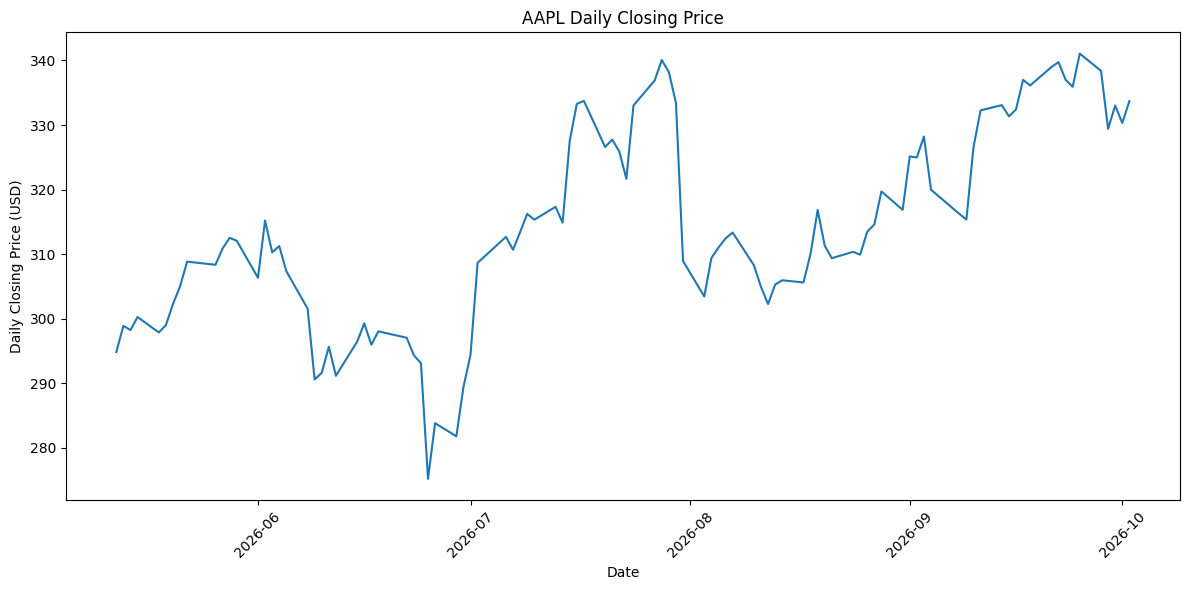

In [17]:
#API key and line graph
import requests
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

API_KEY = userdata.get("ALPHAVANTAGE_API_KEY")

ticker = "AAPL"

url = "https://www.alphavantage.co/query"

params = {
    "function": "TIME_SERIES_DAILY",
    "symbol": ticker,
    "outputsize": "compact",
    "apikey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

# Check that Alpha Vantage actually returned stock data
if "Time Series (Daily)" not in data:
    print(data)
else:
    prices = pd.DataFrame.from_dict(
        data["Time Series (Daily)"],
        orient="index"
    )

    prices.index = pd.to_datetime(prices.index)

    prices = prices.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. volume": "Volume"
    })

    prices = prices.sort_index()

    prices["Close"] = pd.to_numeric(prices["Close"])

    print(prices.head())

    plt.figure(figsize=(12, 6))

plt.plot(prices.index, prices["Close"])

plt.xlabel("Date")
plt.ylabel("Daily Closing Price (USD)")
plt.title(f"{ticker} Daily Closing Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()